# 04 Cohort Retention Analysis

This notebook analyzes customer retention by first purchase month and builds cohort retention tables for the e-commerce dataset.

## 1. Imports and Data Loading

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

orders_path = ROOT_DIR / "data" / "processed" / "orders.csv"

orders = pd.read_csv(orders_path, parse_dates=["invoice_date"])

orders["customer_id"] = orders["customer_id"].astype(str)
orders["invoice_month"] = pd.PeriodIndex(orders["invoice_month"], freq="M")

In [4]:
orders.head()

,invoice_no,customer_id,country,invoice_date,invoice_month,total_quantity,order_revenue,unique_products
0,536365,17850,United Kingdom,2010-12-01 08:26:00,2010-12,40,139.12,7
1,536366,17850,United Kingdom,2010-12-01 08:28:00,2010-12,12,22.20,2
2,536367,13047,United Kingdom,2010-12-01 08:34:00,2010-12,83,278.73,12
3,536368,13047,United Kingdom,2010-12-01 08:34:00,2010-12,15,70.05,4
4,536369,13047,United Kingdom,2010-12-01 08:35:00,2010-12,3,17.85,1


## 2. Dataset Overview

In [5]:
overview = pd.DataFrame(
    {
        "metric": [
            "orders",
            "customers",
            "revenue",
            "first_order_date",
            "last_order_date",
            "months",
        ],
        "value": [
            orders["invoice_no"].nunique(),
            orders["customer_id"].nunique(),
            orders["order_revenue"].sum(),
            orders["invoice_date"].min(),
            orders["invoice_date"].max(),
            orders["invoice_month"].nunique(),
        ],
    }
)

overview

,metric,value
0,orders,18532
1,customers,4338
2,revenue,"8,911,407.90"
3,first_order_date,2010-12-01 08:26:00
4,last_order_date,2011-12-09 12:50:00
5,months,13


- The cleaned dataset contains **18,532 orders** from **4,338 customers**.
- Total analyzed revenue is **£8,911,407.90**.
- The period covers **13 months**: from **2010-12-01** to **2011-12-09**.
- **December 2011 is incomplete**, so it should be treated carefully in month-level comparisons.


## 3. Build Customer Cohorts

In [6]:
customer_first_purchase = (
    orders
    .groupby("customer_id", as_index=False)
    .agg(cohort_month=("invoice_month", "min"))
)

orders_cohort = orders.merge(customer_first_purchase, on="customer_id", how="left")

orders_cohort["order_month"] = orders_cohort["invoice_month"]

orders_cohort["cohort_index"] = (
    (orders_cohort["order_month"].dt.year - orders_cohort["cohort_month"].dt.year) * 12
    + (orders_cohort["order_month"].dt.month - orders_cohort["cohort_month"].dt.month)
)

orders_cohort.head()

,invoice_no,customer_id,country,invoice_date,invoice_month,total_quantity,order_revenue,unique_products,cohort_month,order_month,cohort_index
0,536365,17850,United Kingdom,2010-12-01 08:26:00,2010-12,40,139.12,7,2010-12,2010-12,0
1,536366,17850,United Kingdom,2010-12-01 08:28:00,2010-12,12,22.20,2,2010-12,2010-12,0
2,536367,13047,United Kingdom,2010-12-01 08:34:00,2010-12,83,278.73,12,2010-12,2010-12,0
3,536368,13047,United Kingdom,2010-12-01 08:34:00,2010-12,15,70.05,4,2010-12,2010-12,0
4,536369,13047,United Kingdom,2010-12-01 08:35:00,2010-12,3,17.85,1,2010-12,2010-12,0


## 4. Cohort Sizes

In [7]:
cohort_sizes = (
    orders_cohort
    .loc[orders_cohort["cohort_index"] == 0]
    .groupby("cohort_month", as_index=False)
    .agg(cohort_size=("customer_id", "nunique"))
    .sort_values("cohort_month")
)

cohort_sizes

,cohort_month,cohort_size
0,2010-12,885
1,2011-01,417
2,2011-02,380
3,2011-03,452
4,2011-04,300
5,2011-05,284
6,2011-06,242
7,2011-07,188
8,2011-08,169
9,2011-09,299


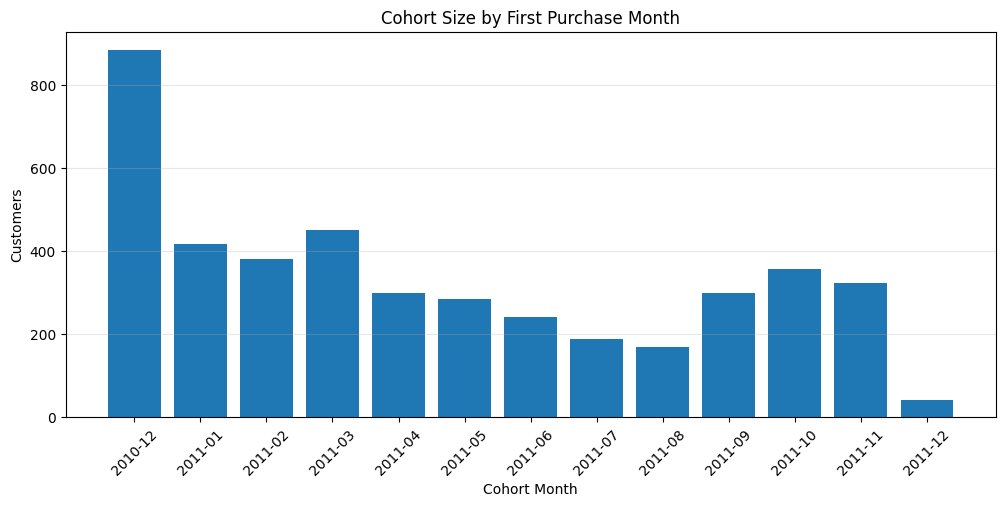

In [8]:
plt.figure(figsize=(12, 5))
plt.bar(cohort_sizes["cohort_month"].astype(str), cohort_sizes["cohort_size"])
plt.title("Cohort Size by First Purchase Month")
plt.xlabel("Cohort Month")
plt.ylabel("Customers")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

- The largest cohort is **2010-12** with **885 customers**.
- The largest 2011 cohort is **2011-03** with **452 customers**.
- The smallest full-month cohort is **2011-08** with **169 customers**.
- **2011-12** has only **41 customers** because the dataset ends on **2011-12-09**.

## 5. Cohort Active Customers

In [9]:
cohort_counts = (
    orders_cohort
    .groupby(["cohort_month", "cohort_index"], as_index=False)
    .agg(active_customers=("customer_id", "nunique"))
)

cohort_counts_matrix = cohort_counts.pivot_table(
    index="cohort_month",
    columns="cohort_index",
    values="active_customers",
)

cohort_counts_matrix

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2010-12,885.00,324.00,286.00,340.00,321.00,352.00,321.00,309.00,313.00,350.00,331.00,445.00,235.00
2011-01,417.00,92.00,111.00,96.00,134.00,120.00,103.00,101.00,125.00,136.00,152.00,49.00,NaN
2011-02,380.00,71.00,71.00,108.00,103.00,94.00,96.00,106.00,94.00,116.00,26.00,NaN,NaN
2011-03,452.00,68.00,114.00,90.00,101.00,76.00,121.00,104.00,126.00,39.00,NaN,NaN,NaN
2011-04,300.00,64.00,61.00,63.00,59.00,68.00,65.00,78.00,22.00,NaN,NaN,NaN,NaN
2011-05,284.00,54.00,49.00,49.00,59.00,66.00,75.00,27.00,NaN,NaN,NaN,NaN,NaN
2011-06,242.00,42.00,38.00,64.00,56.00,81.00,23.00,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.00,34.00,39.00,42.00,51.00,21.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.00,35.00,42.00,41.00,21.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- The **2010-12** cohort starts with **885 customers** and still has **445 active customers** in month 11.
- The **2011-01** cohort starts with **417 customers** and has **152 active customers** in month 10.
- Newer cohorts have fewer observable periods, so later-month values are naturally missing.


## 6. Retention Matrix

In [10]:
retention_matrix = cohort_counts_matrix.div(cohort_counts_matrix.iloc[:, 0], axis=0)

retention_matrix

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2010-12,1.00,0.37,0.32,0.38,0.36,0.40,0.36,0.35,0.35,0.40,0.37,0.50,0.27
2011-01,1.00,0.22,0.27,0.23,0.32,0.29,0.25,0.24,0.30,0.33,0.36,0.12,NaN
2011-02,1.00,0.19,0.19,0.28,0.27,0.25,0.25,0.28,0.25,0.31,0.07,NaN,NaN
2011-03,1.00,0.15,0.25,0.20,0.22,0.17,0.27,0.23,0.28,0.09,NaN,NaN,NaN
2011-04,1.00,0.21,0.20,0.21,0.20,0.23,0.22,0.26,0.07,NaN,NaN,NaN,NaN
2011-05,1.00,0.19,0.17,0.17,0.21,0.23,0.26,0.10,NaN,NaN,NaN,NaN,NaN
2011-06,1.00,0.17,0.16,0.26,0.23,0.33,0.10,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.00,0.18,0.21,0.22,0.27,0.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.00,0.21,0.25,0.24,0.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


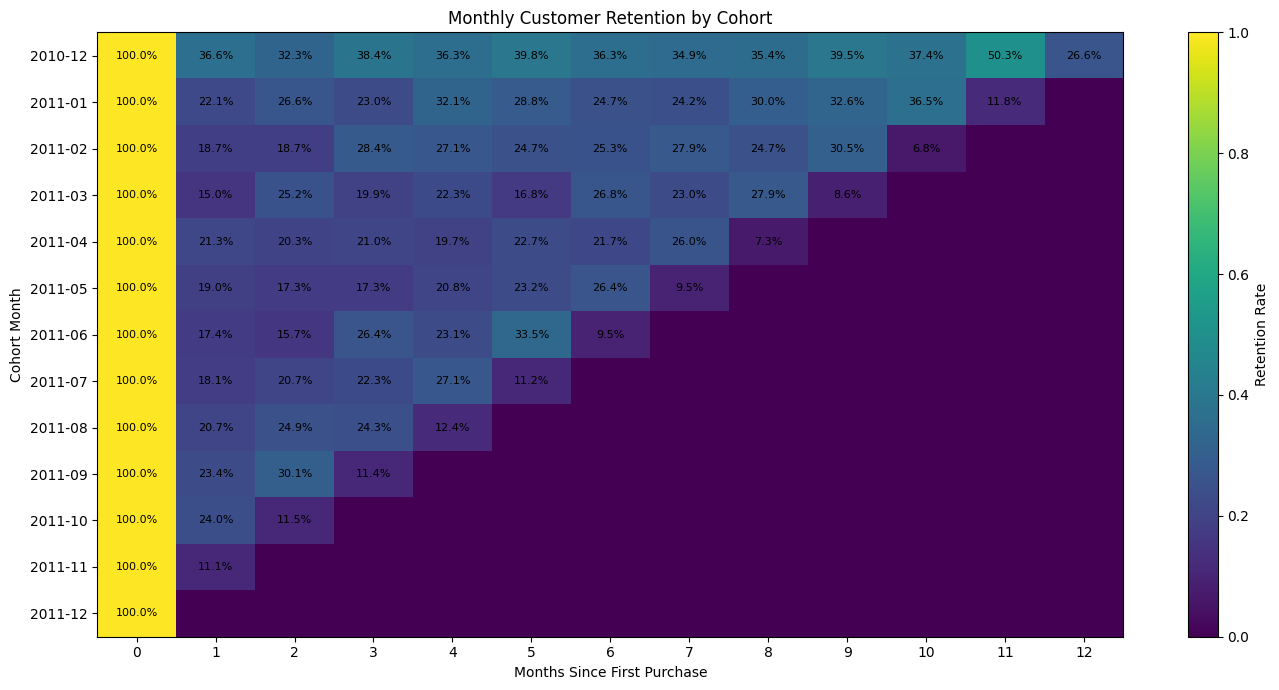

In [11]:
def plot_retention_heatmap(matrix: pd.DataFrame, title: str) -> None:
    plot_data = matrix.copy()
    labels = (plot_data * 100).round(1)

    fig, ax = plt.subplots(figsize=(14, 7))
    im = ax.imshow(plot_data.fillna(0), aspect="auto")

    ax.set_title(title)
    ax.set_xlabel("Months Since First Purchase")
    ax.set_ylabel("Cohort Month")

    ax.set_xticks(np.arange(len(plot_data.columns)))
    ax.set_xticklabels(plot_data.columns)

    ax.set_yticks(np.arange(len(plot_data.index)))
    ax.set_yticklabels(plot_data.index.astype(str))

    for i in range(plot_data.shape[0]):
        for j in range(plot_data.shape[1]):
            value = plot_data.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{labels.iloc[i, j]:.1f}%", ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax, label="Retention Rate")
    plt.tight_layout()
    plt.show()


plot_retention_heatmap(retention_matrix, "Monthly Customer Retention by Cohort")

- Average month-1 retention is about **21%**.
- The strongest month-1 retention is in the **2010-12** cohort: **37%**.
- The weakest month-1 retention is in the **2011-11** cohort: **11%**.
- The **2010-12** cohort reaches **50% retention** in month 11.

## 7. Full-Month Retention Matrix

In [12]:
last_month = orders["invoice_month"].max()

orders_full_months = orders_cohort[orders_cohort["order_month"] < last_month].copy()

cohort_counts_full = (
    orders_full_months
    .groupby(["cohort_month", "cohort_index"], as_index=False)
    .agg(active_customers=("customer_id", "nunique"))
)

cohort_counts_full_matrix = cohort_counts_full.pivot_table(
    index="cohort_month",
    columns="cohort_index",
    values="active_customers",
)

retention_matrix_full = cohort_counts_full_matrix.div(cohort_counts_full_matrix.iloc[:, 0], axis=0)

retention_matrix_full

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,,
2010-12,1.00,0.37,0.32,0.38,0.36,0.40,0.36,0.35,0.35,0.40,0.37,0.50
2011-01,1.00,0.22,0.27,0.23,0.32,0.29,0.25,0.24,0.30,0.33,0.36,NaN
2011-02,1.00,0.19,0.19,0.28,0.27,0.25,0.25,0.28,0.25,0.31,NaN,NaN
2011-03,1.00,0.15,0.25,0.20,0.22,0.17,0.27,0.23,0.28,NaN,NaN,NaN
2011-04,1.00,0.21,0.20,0.21,0.20,0.23,0.22,0.26,NaN,NaN,NaN,NaN
2011-05,1.00,0.19,0.17,0.17,0.21,0.23,0.26,NaN,NaN,NaN,NaN,NaN
2011-06,1.00,0.17,0.16,0.26,0.23,0.33,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.00,0.18,0.21,0.22,0.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.00,0.21,0.25,0.24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


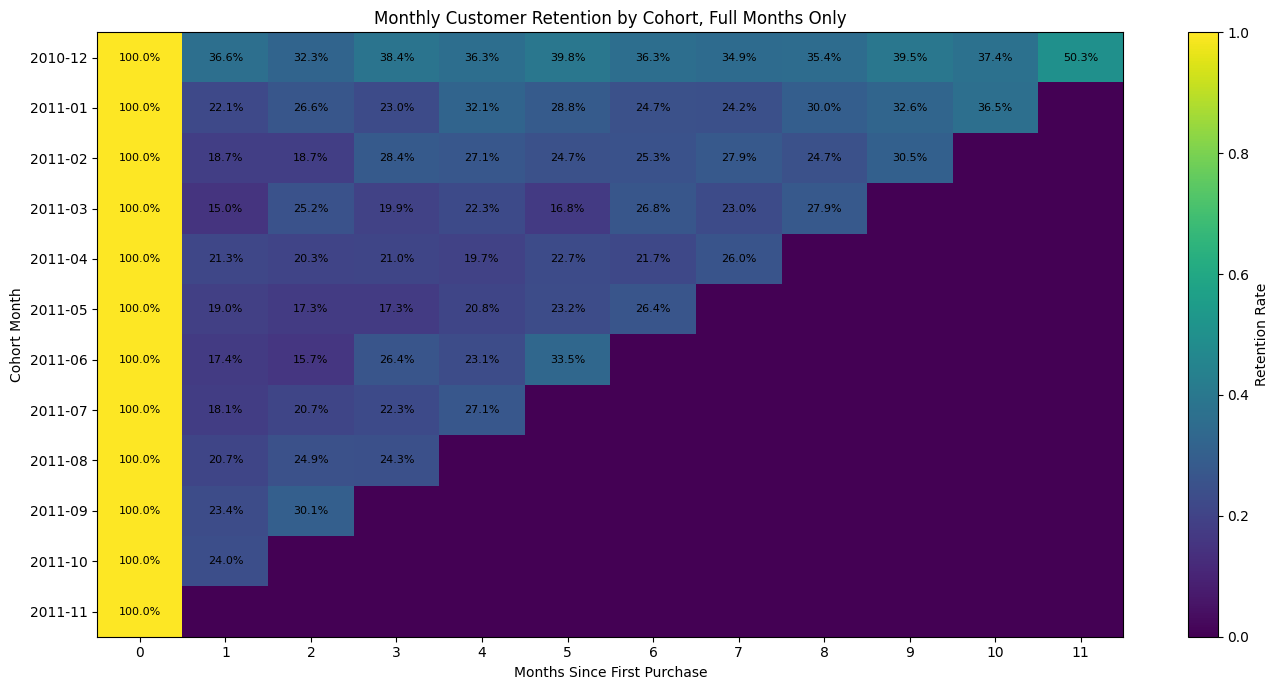

In [13]:
plot_retention_heatmap(retention_matrix_full, "Monthly Customer Retention by Cohort, Full Months Only")

- The full-month matrix excludes the incomplete **2011-12** period.
- The **2010-12** cohort remains the strongest long-term cohort with **50% retention** in month 11.
- The **2011-01** cohort reaches **36% retention** in month 10.
- Several cohorts show stronger activity in later months, which may indicate seasonal reactivation.

## 8. Retention Summary

In [14]:
def get_retention_value(row: pd.Series, month: int) -> float:
    if month in row.index and pd.notna(row[month]):
        return row[month]
    return np.nan


retention_summary = retention_matrix.copy()

cohort_summary = pd.DataFrame(
    {
        "cohort_month": retention_summary.index.astype(str),
        "cohort_size": cohort_counts_matrix.iloc[:, 0].astype(int).values,
        "m1_retention": retention_summary.apply(lambda row: get_retention_value(row, 1), axis=1).values,
        "m2_retention": retention_summary.apply(lambda row: get_retention_value(row, 2), axis=1).values,
        "m3_retention": retention_summary.apply(lambda row: get_retention_value(row, 3), axis=1).values,
        "m6_retention": retention_summary.apply(lambda row: get_retention_value(row, 6), axis=1).values,
        "m12_retention": retention_summary.apply(lambda row: get_retention_value(row, 12), axis=1).values,
    }
)

cohort_summary

,cohort_month,cohort_size,m1_retention,m2_retention,m3_retention,m6_retention,m12_retention
0,2010-12,885,0.37,0.32,0.38,0.36,0.27
1,2011-01,417,0.22,0.27,0.23,0.25,NaN
2,2011-02,380,0.19,0.19,0.28,0.25,NaN
3,2011-03,452,0.15,0.25,0.20,0.27,NaN
4,2011-04,300,0.21,0.20,0.21,0.22,NaN
5,2011-05,284,0.19,0.17,0.17,0.26,NaN
6,2011-06,242,0.17,0.16,0.26,0.10,NaN
7,2011-07,188,0.18,0.21,0.22,NaN,NaN
8,2011-08,169,0.21,0.25,0.24,NaN,NaN
9,2011-09,299,0.23,0.30,0.11,NaN,NaN


- Month-1 retention ranges from **11%** to **37%**.
- Average month-3 retention is about **23%**.
- The strongest month-3 retention is **38%** for the **2010-12** cohort.
- Month-6 retention ranges from **10%** to **36%** among cohorts with enough history.

## 9. Average Retention by Month Since First Purchase

In [15]:
average_retention_by_period = (
    retention_matrix
    .drop(columns=[0], errors="ignore")
    .mean(axis=0, skipna=True)
    .reset_index()
)

average_retention_by_period.columns = ["cohort_index", "average_retention"]

average_retention_by_period

,cohort_index,average_retention
0,1,0.21
1,2,0.22
2,3,0.23
3,4,0.25
4,5,0.25
5,6,0.24
6,7,0.24
7,8,0.25
8,9,0.28
9,10,0.27


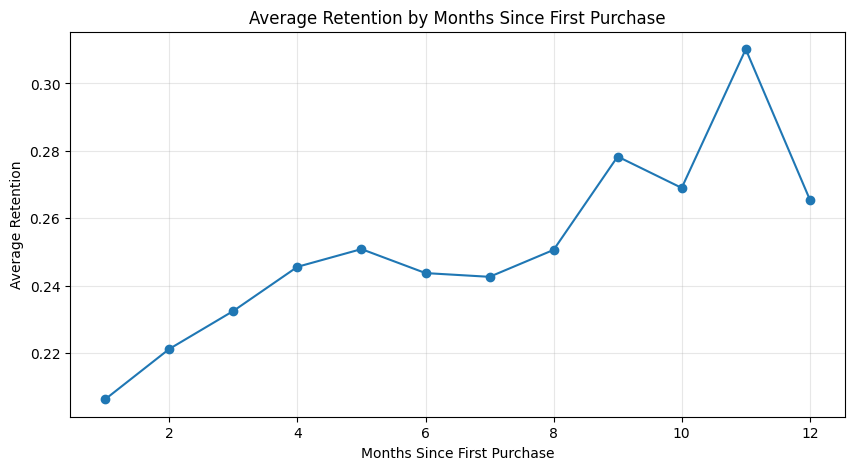

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(
    average_retention_by_period["cohort_index"],
    average_retention_by_period["average_retention"],
    marker="o",
)
plt.title("Average Retention by Months Since First Purchase")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Average Retention")
plt.grid(True, alpha=0.3)
plt.show()

- Average retention is **21%** after 1 month.
- Average retention is **23%** after 3 months.
- Average retention is **24%** after 6 months.
- The highest average retention is **31%** in month 11.

## 10. Revenue by Cohort

In [17]:
cohort_revenue = (
    orders_cohort
    .groupby(["cohort_month", "cohort_index"], as_index=False)
    .agg(revenue=("order_revenue", "sum"))
)

cohort_revenue_matrix = cohort_revenue.pivot_table(
    index="cohort_month",
    columns="cohort_index",
    values="revenue",
)

cohort_revenue_matrix

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2010-12,"572,713.89","276,237.69","233,845.37","303,119.39","204,407.66","336,627.50","314,162.61","310,783.92","331,749.22","472,813.64","456,080.61","513,803.59","185,803.13"
2011-01,"293,207.35","55,149.91","63,268.17","71,587.40","81,114.09","84,583.78","70,107.40","72,689.71","72,023.65","111,803.90","123,882.10","26,464.82",NaN
2011-02,"158,142.07","29,043.24","41,134.38","48,238.86","40,147.91","34,223.23","49,706.63","62,450.83","55,380.06","64,809.45","10,600.22",NaN,NaN
2011-03,"200,069.96","30,059.43","59,057.51","42,816.61","51,657.33","40,020.81","64,919.49","71,023.95","71,265.83","12,868.02",NaN,NaN,NaN
2011-04,"122,011.49","29,452.82","25,077.07","24,311.47","26,314.19","30,206.30","28,668.98","34,228.61","6,350.10",NaN,NaN,NaN,NaN
2011-05,"124,103.78","18,682.76","20,193.76","19,162.17","27,861.87","32,976.60","33,312.91","179,251.53",NaN,NaN,NaN,NaN,NaN
2011-06,"135,742.95","14,805.15","14,155.40","30,961.59","26,754.54","42,808.25","8,227.35",NaN,NaN,NaN,NaN,NaN,NaN
2011-07,"74,008.75","11,789.67","15,534.18","17,551.47","19,512.11","6,072.16",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,"79,756.10","20,962.93","35,503.90","44,541.76","15,284.36",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- The **2010-12** cohort generated **£4.51M**, which is about **50.6%** of total revenue.
- The **2011-01** cohort generated **£1.13M** in total revenue.
- The **2010-12** cohort also has the highest first-month revenue: **£572.7K**.
- Early cohorts dominate revenue because they are larger and have a longer observation window.

## 11. Save Outputs

In [18]:
output_dir = ROOT_DIR / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

cohort_counts.to_csv(output_dir / "cohort_counts.csv", index=False)
cohort_sizes.to_csv(output_dir / "cohort_sizes.csv", index=False)
cohort_summary.to_csv(output_dir / "cohort_summary.csv", index=False)

retention_matrix_to_save = retention_matrix.copy()
retention_matrix_to_save.index = retention_matrix_to_save.index.astype(str)
retention_matrix_to_save.to_csv(output_dir / "cohort_retention.csv")

retention_matrix_full_to_save = retention_matrix_full.copy()
retention_matrix_full_to_save.index = retention_matrix_full_to_save.index.astype(str)
retention_matrix_full_to_save.to_csv(output_dir / "cohort_retention_full_months.csv")

cohort_revenue_matrix_to_save = cohort_revenue_matrix.copy()
cohort_revenue_matrix_to_save.index = cohort_revenue_matrix_to_save.index.astype(str)
cohort_revenue_matrix_to_save.to_csv(output_dir / "cohort_revenue.csv")

average_retention_by_period.to_csv(output_dir / "average_retention_by_period.csv", index=False)

print("Saved cohort retention outputs to:", output_dir)

Saved cohort retention outputs to: D:\pychramProjects\E-commerce-Analytics\data\processed


## Findings
- The dataset covers **18,532 orders**, **4,338 customers** and **£8.91M** in revenue across **13 months**.
- Customer retention is meaningful: average month-1 retention is **21%**, and average month-6 retention is **24%**.
- The strongest cohort is **2010-12**: **885 customers**, **37%** month-1 retention, **50%** retention in month 11 and **£4.51M** total revenue.
- **December 2011 is incomplete**, so it should not be directly compared with full months.
- The cohort pattern suggests that retention and seasonal reactivation are important revenue drivers for this business.